# Lab 4: Towards quantum advantage

# Chapter 3: Classically verifiable problems: QAOA for partition problem

*Usage estimate of QPU time for the notebook excluding the bonus part: 5 min 30 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The QPU usage estimate reflects only backend execution time. Queueing, calibration, and runtime session delays can extend total execution to several minutes, even for workloads using only seconds of QPU time.*

In Lab 4a, we explored what quantum advantage means and how the [Quantum Advantage Tracker](https://quantum-advantage-tracker.github.io/) classifies demonstrations into three categories: classically verifiable problems, variational problems, and observable estimation. We saw examples like the $ \mathrm{Fe}_4\mathrm{S}_4$ molecule computation (variational) and the Loschmidt Echo calculation (observable estimation).

Now we turn to the first category: **classically verifiable problems**. These are optimization problems where we can efficiently verify if a quantum solution is correct, even if finding that solution classically is exponentially hard. This makes them ideal candidates for demonstrating quantum advantage, since we can prove the quantum computer found a good answer without needing an equally powerful classical computer to check it.

In this lab, we will explore the [Quantum Approximate Optimization Algorithm (QAOA)](https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice/utility-scale-qaoa) applied to the Partition Problem. QAOA is particularly promising because:
- It is designed for near-term quantum hardware (no error correction needed)
- Solutions are easy to verify classically
- It has the potential to demonstrate quantum advantage as we scale to larger problem sizes

The partition problem asks: given a set of numbers, can we split them into two groups with equal sums? While this sounds simple, it becomes exponentially harder as the problem size grows, making it a perfect testbed for quantum advantage. Let's see how QAOA tackles it!

### Install the necessary libraries

In [ ]:
# %pip install qc-grader
# %pip install mthree
# %pip install qiskit-addon-opt-mapper
# %pip install git+https://github.com/qiskit-community/qopt-best-practices.git
# %pip install qiskit-aer
# %pip install matplotlib
# %pip install pandas
# %pip install pylatexenc

### Setting up the `utils` folder

Wether you use a local environment (such as [VSCode](https://code.visualstudio.com/)) or an online enviornment (such as [qBraid](https://www.qbraid.com/)), make sure that you place the `utils` folder in the same directory as the notebook. Otherwise you will receive a ModuleNotFoundError when you execute the Imports cell.

### Imports

In [ ]:
from qc_grader.challenges.qgss_2026 import (
    check_progress,
    grade_lab4b_ex1a,
    grade_lab4b_ex1b,
    grade_lab4b_ex2a,
    grade_lab4b_ex2b,
    grade_lab4b_ex2c,
    grade_lab4b_ex2d,
    grade_lab4b_ex2,
    grade_lab4b_ex3a,
    grade_lab4b_ex3b,
    grade_lab4b_ex3c,
    grade_lab4b_ex4a,
    grade_lab4b_ex4b,
    grade_lab4b_ex4c,
    grade_lab4b_ex4d,
    grade_lab4b_ex4,
    grade_lab4b_exbonus,
)

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

from scipy.optimize import minimize
import networkx as nx
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.options import SamplerOptions, EstimatorOptions
import mthree

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz
from qopt_best_practices.transpilation import UnrollBoxes

from qiskit.transpiler import CouplingMap
from qopt_best_practices.transpilation.generate_preset_qaoa_pass_manager import (
    generate_preset_qaoa_pass_manager,
)
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from itertools import combinations

# Import utils
from utils.functions import plot_partition_graph, analyze_partition_result
from utils.functions import (
    analyze_error_mitigation_result,
    compare_error_mitigation_methods,
    plot_error_mitigation_comparison,
    print_comparison_summary,
)
from utils.functions import get_partitions, calc_cut_size

from random import sample

# Set seed for reproducibility
seed = 42

Throughout the Lab you can use the `check_progress` function to see how many exercises you have completed:

In [ ]:
check_progress()

We choose the backend

In [ ]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=156)
print(f"We are using {backend.name}")

Note that this lab is intended to be run on a QPU. However, if you run out of QPU time, you can still complete most of it (everything except part (b) of the Bonus exercise) using a simulator. To do so, uncomment the following cell

In [ ]:
# from qiskit_aer import AerSimulator
# backend = AerSimulator.from_backend(backend)

## The Partition Problem:

The Partition Problem seeks to divide a set of numbers into two groups such that the difference between their total sums is as small as possible, with the special case of zero difference corresponding to perfectly equal partitions. 
It has numerous real‑world applications across different areas, including logistics, finance, and resource allocation. We can illustrate this with a small day-to-day example.

Imagine you're packing groceries into two identical backpacks for a camping trip.
You have six items, each with a different weight:

- Milk bottle: 3 kg
- Flour bag: 5 kg
- Rice pack: 7 kg
- Watermelon: 9 kg
- Olive oil bottle: 11 kg
- Water pack: 13 kg

Your goal is to pack the groceries into the two backpacks so that both backpacks weigh exactly the same.
Can you do it?

While this may seem simple for a small number of items, the Partition Problem is an NP‑hard problem, which means that while it is straightforward to verify whether a proposed solution is correct, simply by summing the elements in each subset, it is computationally very difficult to actually find such a solution in the first place, as no efficient algorithm is known.


Mathematically, the Partition Problem can be formulated as an optimization task in which we aim to divide the set into two subsets that can be of different size and whose sums are as close as possible. This corresponds to minimizing the absolute difference between the sums of the two subsets:

$$\min_{S_1, S_2} \left| \sum_{a_i \in S_1} a_i - \sum_{a_j \in S_2} a_j \right|$$

For our simple example $S = \{3, 5, 7, 9, 11, 13\}$, the solution is:
- Backpack 1: $\{3, 5, 7, 9\}$ → 24 kg 
- Backpack 2: $\{11, 13\}$ → 24 kg

This is a valid partition because both subsets sum to 24 kg.

Finding this solution by hand was easy for 6 numbers, but what about 100? Or 1000?
For $n$ elements, there are $2^n$ possible partitions to check. For just 50 elements, that's over 1 quadrillion possibilities!


This is where **quantum computing** enters the story...


### From partition problem to Hamiltonian formalism

#### QUBO formalism

To try to solve this problem using a quantum computer, first we need to rewrite it as a Quadratic Unconstrained Binary Optimization (QUBO) problem.

#### Binary Encoding

Use binary variables $x_i \in \{0, 1\}$:
- $x_i = 0$ → element $a_i$ in subset $S_1$
- $x_i = 1$ → element $a_i$ in subset $S_2$

#### Objective Function

The cost (imbalance) between subsets:

$$C = \sum_{i: x_i=1} a_i - \sum_{i: x_i=0} a_i = \sum_{i=1}^n a_i(2x_i - 1)$$

We minimize $C^2$ to avoid absolute values:

$$\min_{x \in \{0,1\}^n} C^2 = \min_{x \in \{0,1\}^n} \left(\sum_{i=1}^n a_i(2x_i - 1)\right)^2$$

If we expand this, we can see that our cost function is going to represent a QUBO problem for our variables $x_i$.

### From QUBO to Ising Hamiltonian
Let us now try to rewrite this QUBO problem by using spin variables $z_i \in \{-1, +1\}$ instead of binary, related by:
$$x_i = \frac{1-z_i}{2}$$

Substituting into the cost:

$$C = \sum_{i=1}^n a_i(2x_i - 1) = -\sum_{i=1}^n a_i z_i$$

using $\left(\sum_i x_i\right)^2=\sum_i\sum_j x_i x_j$ and $x_i=a_i z_i$ we obtain:

$$C^2 = \sum_{i,j} a_i a_j z_i z_j$$

Splitting the double sum into the cases $i=j$ and $i\neq j$:

$$C^2=\sum_i a_i^2 z_i^2+\sum_{i\neq j} a_i a_j z_i z_j$$

Since Ising spins satisfy $z_i^2=1$ the first term becomes a constant:

$$\sum_i a_i^2 z_i^2 = \sum_i a_i^2$$

So

$$C^2= \sum_i a_i^2 + \sum_{i\neq j} a_i a_j z_i z_j$$

Using symmetry, each pair $(i,j)$ appears twice: $a_i a_j z_i z_j$ and $a_j a_i z_j z_i$; because they are identical, we can write:

$$\sum_{i\neq j} a_i a_j z_i z_j = 2\sum_{i<j} a_i a_j z_i z_j$$

Therefore

$$C^2= \underbrace{\sum_i a_i^2}_{\text{constant}} + 2\sum_{i<j} a_i a_j z_i z_j$$

Since constants do not affect the minimizer, we can drop them and obtain:

$$ C^2 = 2\sum_{i<j} a_i a_j z_i z_j$$

where the factor of 2 is often absorbed into the coupling coefficients or ignored because an overall scaling does not change the optimal bitstring. The only thing that matters for optimization is that the coupling between qubits $i$ and $j$ is proportional to $a_i a_j$. Replacing classical spins with Pauli-Z operators gives the cost Hamiltonian:

$$H_C = \sum_{i<j} a_i a_j Z_i Z_j$$

where each term's weight is the product of two numbers $a_i a_j$.
Now we can find the eigenvector of this Cost Hamiltonian by using the [QAOA algorithm](https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice/utility-scale-qaoa), which is what we will be doing in this Lab.

# 1. We define the partition problem example

In [ ]:
# Define our partition problem
numbers = [3, 5, 7, 9, 11, 13]

n = len(numbers)

print(f"Numbers to partition: {numbers}")
print(f"Total sum: {sum(numbers)}")
print(f"Target sum per partition: {sum(numbers) / 2}")

<a id="exercise_1"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 1a: Define the graph that defines the partition problem </b> 

**Your Goal:** Define the graph that defines the partition problem.

In this first exercise, you will create a weighted graph representation of the partition problem. This is a crucial step in transforming the partition problem into a form that QAOA can solve.

**Background:** The partition problem can be mapped to a MaxCut problem on a complete graph. In this representation:
- Each number in our set represents a **node** in the graph
- Every pair of nodes is connected by an **edge**
- The **weight** of each edge is the product of the two numbers it connects


**Hint:** Use NetworkX's graph functions. You'll need to iterate through all pairs of nodes and add weighted edges.

</div>

Here are the links to [NetworkX documentation](https://networkx.org/documentation/stable/reference/index.html), [NetworkX graph class](https://networkx.org/documentation/stable/reference/classes/graph.html#overview), and a [NetworkX tutorial](https://networkx.org/documentation/stable/tutorial.html)

In [ ]:
def build_partition_graph(numbers: list[int])  -> nx.Graph:
    """
    Create a complete weighted graph where edge weights are the product
    of the corresponding values in `numbers`.

    Parameters
    ----------
    numbers : list or sequence of numbers
        Values used to compute edge weights.

    Returns
    -------
    partition_graph : networkx.Graph
        Graph with n nodes and weighted edges.
    """
    n = len(numbers)
    nodes = range(n)
    # ---- TODO : Task 1a ---
    # Create a complete graph where each node represents a number

    # Add edges with weights = product of the two numbers
    # This encoding ensures that cutting between different-valued nodes
    # contributes more to the objective
    
    # ---- end of TODO : Task 1a ---
    return partition_graph


partition_graph = build_partition_graph(numbers)


In [ ]:
plot_partition_graph(partition_graph, numbers, seed=seed, show=True)

In [ ]:
## Verify your answer ##
grade_lab4b_ex1a(partition_graph)

Now let's use QAOA to solve this partition problem by finding the MaxCut!

We'll convert the graph to a cost Hamiltonian, which in this case will be the partition Hamiltonian, and apply QAOA to find the optimal partition. To do that we encourage you to explore the [`qiskit_addon_opt_mapper`](https://qiskit.github.io/qiskit-addon-opt-mapper/) library and [`qopt_best_practices`](https://github.com/qiskit-community/qopt-best-practices) libraries to create the QAOA circuit and optimize its parameters.

<a id="exercise_1b"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 1b: From graph to Hamiltonian and quantum circuit </b> 

**Your Goal:** Convert the graph representation into the cost Hamiltonian and construct the QAOA circuit using the `qiskit_addon_opt_mapper`and `qopt_best_practices` libraries.

Note that the cost Hamiltonian is the partition Hamiltonian and needs to be a SparsePauliOp object.

In this exercise, you will transform the classical graph problem into a QAOA quantum circuit whose parameters we can optimize. This involves two key steps: creating the partition Hamiltonian that encodes the MaxCut objective, and building a parameterized quantum circuit.

**Hint:** Review the import statements at the top of the notebook to see which functions you might need.
Also take a look at the output of the [`to_ising`](https://github.com/Qiskit/qiskit-addon-opt-mapper/blob/main/qiskit_addon_opt_mapper/translators/ising.py#L24) function, and note that the function needs to take an `OptimizationProblem` input, not a [`Maxcut`](https://qiskit.github.io/qiskit-addon-opt-mapper/stubs/qiskit_addon_opt_mapper.applications.Maxcut.html#qiskit_addon_opt_mapper.applications.Maxcut) class.

</div>


In [ ]:
layers = 1

# ---- TODO : Task 1b ---
maxcut = 
partition_hamiltonian = 
# Note that we created an annotated_qaoa_ansatz circuit where the individual QAOA cost 
# and QAOA mixer layers are annotated for improved transpilation
circuit = 

# ---- end of TODO : Task 1b ---

# Now we draw the circuit and add the measurements for sampling
circuit_sampler = circuit.copy()
circuit_sampler.measure_all()
circuit.draw(idle_wires=False, fold=-1, output="mpl")

In [ ]:
## Verify your answer ##
grade_lab4b_ex1b(partition_hamiltonian, circuit)

In [ ]:
# Create pass manager for transpilation
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend, seed_transpiler=seed
)
edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})

num_colors = len(set(edge_coloring.values()))


# Make an empty swap strategy as we have a hardware-native graph here
cmap = CouplingMap(partition_graph.edges())
cmap.make_symmetric()

swap_strategy = SwapStrategy(cmap, ())  # no SWAPs needed

staged_pm = generate_preset_qaoa_pass_manager(
    backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring
)
# pm = staged_pm
candidate_circuit = pm.run(UnrollBoxes()(circuit))
candidate_circuit_sampler = pm.run(UnrollBoxes()(circuit_sampler))
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

Now, we run the QAOA algorithm. You can either use the pre-trained parameters directly as an approximate solution by setting `training=False`, to skip the optimization step, or use them as an initial guess by passing them via `init_params` and setting `training=True`, allowing you to further optimize them and evaluate how much you can improve the results.

If you are not familiar with optimization loops in [Variational Quantum Algorithms](https://quantum.cloud.ibm.com/learning/courses/variational-algorithm-design/variational-algorithms) we recommend reviewing [this course](https://quantum.cloud.ibm.com/learning/courses/variational-algorithm-design/optimization-loops). For a more in-depth approach, you can also explore [this tutorial](https://quantum.cloud.ibm.com/docs/tutorials/quantum-approximate-optimization-algorithm) to see these concepts applied in a QAOA scenario.

In [ ]:
training = False
init_params = np.load("utils/pretrained_parameters_small.npy")

In [ ]:
objective_func_vals = []  # Global variable


def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost


max_iter = 30

if training:
    # Try with Session session, fallback to Job mode if it fails
    try:
        session = Session(backend=backend)
        estimator = Estimator(mode=session)
        use_session = True
        print("We are using Session mode")
    except:
        estimator = Estimator(mode=backend)
        use_session = False
        print("We are using Job mode")

    estimator.options.default_shots = 10000
    estimator.options.environment.job_tags = ["qgss26"]

    if use_session:
        with session:
            result = minimize(
                cost_func_estimator,
                init_params,
                args=(candidate_circuit, partition_hamiltonian, estimator),
                method="COBYLA",
                options={"maxiter": max_iter, "tol": 1e-8, "rhobeg": 0.001},
            )
    else:
        result = minimize(
            cost_func_estimator,
            init_params,
            args=(candidate_circuit, partition_hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": max_iter, "tol": 1e-8, "rhobeg": 0.001},
        )

    optimized_params = result.x
    np.save("optimized_parameters_small_custom.npy", optimized_params)
    plt.figure(figsize=(12, 6))
    plt.plot(objective_func_vals, lw=0.75, marker=".")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()


else:
    optimized_params = np.load("utils/pretrained_parameters_small.npy")
optimized_circuit = candidate_circuit_sampler.assign_parameters(optimized_params)

# 2. Applying different Error Mitigation and Suppression techniques to the Sampler

Now we are going to apply different [error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques) to try to get the best results for the partition problem. This will complement the techniques you learned in Lab 3 from a more practical perspective - in particular, in a quantum optimization setting. 

<a id="exercise_2"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 2: Use the Sampler with different levels of Error Mitigation techniques</b>

**Your Goal:** Apply different error mitigation techniques to the quantum circuit execution and compare the results.

Test the following four configurations using 1000 shots:

- **2a: No Error Mitigation or Suppression** (baseline)  
  Raw hardware results without any error mitigation or suppression techniques

- **2b: Error Suppression + Twirling**  
  Dynamical Decoupling + Pauli Twirling (gates and measure) to suppress coherent errors during circuit execution

- **2c: M3 Error Mitigation Only**  
  Matrix-free Measurement Mitigation to correct readout errors in post-processing

- **2d: M3 Error Mitigation + Error Suppression + Twirling** (full stack)  
  Combined approach using both suppression during execution and mitigation in post-processing

Compare the accuracy and performance of each approach to understand the impact of different error mitigation strategies.

</div>

First we will define the [`SamplerOptions`](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-sampler-options) object for each case and then we will run the workflows.

In [ ]:
# =============================================================================
# VERSION 1: No Error Mitigation or Suppression
# =============================================================================
print("=" * 80)
print("VERSION 1: No Error Mitigation or Suppression")
print("=" * 80)

options_v1 = SamplerOptions()
# ---- TODO : Task 2a ---
# Set the number of shots to 1000 and define the SamplerOptions for the quantum circuit execution
shots = 
options_v1.default_shots = 
# ---- end of TODO : Task 2a ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex2a(options_v1)

Now apply [Dynamical Decoupling](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-dynamical-decoupling-options) and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-twirling-options) (gates and measure twirling). 

In [ ]:
# =============================================================================
# VERSION 2: Error Suppression Only (Dynamical Decoupling + Twirling)
# =============================================================================
print("=" * 80)
print("VERSION 2: Error Suppression Only")
print("=" * 80)


options_v2 = SamplerOptions()
# ---- TODO : Task 2b ---
# Configure error suppression options
options_v2.default_shots = 
# Set dynamical decoupling to reduce decoherence errors
options_v2.dynamical_decoupling.enable = 
options_v2.dynamical_decoupling.sequence_type = 
# Enable gate twirling to randomize coherent errors
options_v2.twirling.enable_gates = 
# Enable measurement twirling to randomize readout errors
options_v2.twirling.enable_measure = 
options_v2.twirling.num_randomizations = 

# ---- end of TODO : Task 2b ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex2b(options_v2)

Now that you have succesfully completed Ex2a and Ex2b, we will run those workflows to use the results to be further post-processed by the M3 technique.

*Usage estimate: 5 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 1: No Error Mitigation or Suppression
# =============================================================================
# No error mitigation or suppression options set
sampler_v1 = Sampler(mode=backend, options=options_v1)
sampler_v1.options.environment.job_tags = ["qgss26"]

pub_v1 = (optimized_circuit,)
job_v1 = sampler_v1.run([pub_v1], shots=shots)
print ("Job ID of job_v1:", job_v1.job_id())
counts_bin_v1 = job_v1.result()[0].data.meas.get_counts()

final_distribution_bin_v1 = {key: val / shots for key, val in counts_bin_v1.items()}

final_distribution_bin_v1 = dict(
    sorted(final_distribution_bin_v1.items(), key=lambda item: item[1], reverse=True)
)
print("Results (no mitigation):")
print(final_distribution_bin_v1)

**Troubleshooting: Retrieving Lost Jobs**

If you lose access to your job variables due to a kernel restart or session interruption, you can still retrieve your results without rerunning the job on hardware. This saves valuable QPU time. Execute the cell below to retrieve a job using its job ID.

If you do not have the job ID readily available, you can find it in [IBM Quantum Platform](https://quantum.cloud.ibm.com/) by checking your job history under the Jobs tab.

In [ ]:
job_id_v1= job_v1.job_id()
# Alternatively, you can also subsittute the job_id_v1 by the actual string of the job ID, e.g. "d8slqn5bh0os73eoe0lk"
job_v1_retrieved = service.job(job_id_v1)

*Usage estimate: 5 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 2: Error Suppression Only (Dynamical Decoupling + Twirling)
# =============================================================================
sampler_v2 = Sampler(mode=backend, options=options_v2)
sampler_v2.options.environment.job_tags = ["qgss26"]

pub_v2 = (optimized_circuit,)
job_v2 = sampler_v2.run([pub_v2], shots=shots)
print ("Job ID of job_v2:", job_v2.job_id())
counts_bin_v2 = job_v2.result()[0].data.meas.get_counts()
final_distribution_bin_v2 = {key: val / shots for key, val in counts_bin_v2.items()}
final_distribution_bin_v2 = dict(
    sorted(final_distribution_bin_v2.items(), key=lambda item: item[1], reverse=True)
)
print("Results (error suppression only):")
print(final_distribution_bin_v2)
print()

After running these two workflows, we can use the obtained counts to be analyzed by M3.

The M3 ([Matrix‑free Measurement Mitigation](https://qiskit.github.io/qiskit-addon-mthree/)) method is a scalable approach to readout error mitigation that avoids constructing the full $2^n \times 2^n$ assignment matrix by using simplified models of readout errors. It assumes that correlations of order three and higher are negligible, which allows it to rely only on single-qubit and two-qubit assignment matrices obtained by preparing all qubits in the $\lvert 0\ldots0\rangle$ and $\lvert 1\ldots1\rangle$ states and measuring their error rates. These small $2\times2$ and $4\times4$ matrices are stored and later combined to form an effective mitigation matrix that is built only from the bitstrings observed during sampling. Because the size of this effective matrix grows with the number of sampled outcomes rather than $2^n$, M3 can be applied to circuits with much longer bitstrings than traditional linear algebra methods.

Now you are asked to use it to reduce the error in the sampling of the quantum circuit. See this [tutorial](https://quantum.cloud.ibm.com/docs/tutorials/readout-error-mitigation-sampler) for a more in-depth analysis. Also, if you want a more hands-on approach to see which functions you need to apply, see [this tutorial](https://qiskit.github.io/qiskit-addon-mthree/tutorials/01_M3_ex1.html).

*Usage estimate: 7 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 3: M3 Error Mitigation Only
# =============================================================================
print("=" * 80)
print("VERSION 3: M3 Error Mitigation Only")
print("=" * 80)

# We copy the setup from version 1, but focus only on M3 mitigation
options_v3 = options_v1
counts_bin_v3 = counts_bin_v1
job_v3 = job_v1
# ---- TODO : Task 2c ---
# Get the physical qubit mapping from the optimized circuit using the mthree.utils.final_measurement_mapping function

meas_map_v3 = 

# Build mitigator using mthree.M3Mitigation
mit_v3 = 

# Calibrate the mitigator using the .cals_from_system method and the meas_map_v3

# Use the .apply_correction method on counts_bin_v3 to returns quasi-probabilities
m3_quasis_v3 = 
# ---- end of TODO : Task 2c ---

def convert_bin_list(dist, shots=10000):
    # Step 1: convert to (non-negative) counts
    counts = {
        k: (int(round(float(v) * shots)) if float(v) >= 0 else 0)
        for k, v in dist.items()
    }
    # Step 2: normalize
    total_counts = sum(counts.values())
    return {k: round(v / total_counts, int(np.log10(shots))) for k, v in counts.items()}


final_distribution_bin_v3 = convert_bin_list(dict(m3_quasis_v3), shots=shots)
final_distribution_bin_v3 = dict(
    sorted(final_distribution_bin_v3.items(), key=lambda item: item[1], reverse=True)
)
print("Results (M3 mitigation only):")
print(final_distribution_bin_v3)
print()

In [ ]:
## Verify your answer ##
grade_lab4b_ex2c(options_v3, optimized_circuit, meas_map_v3, m3_quasis_v3, counts_bin_v3)

*Usage estimate: 7 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 4: M3 Error Mitigation + Error Suppression
# =============================================================================
print("=" * 80)
print("VERSION 4: M3 Error Mitigation + Error Suppression")
print("=" * 80)

options_v4 = options_v2
counts_bin_v4 = counts_bin_v2
job_v4 = job_v2
# ---- TODO : Task 2d ---
# Apply M3 correction on top of error suppression
# Get the physical qubit mapping from the optimized circuit using the mthree.utils.final_measurement_mapping function

meas_map_v4 = 

# Build mitigator using mthree.M3Mitigation
mit_v4 = 

# Calibrate the mitigator using the .cals_from_system method and the meas_map_v4

# Use the .apply_correction method on counts_bin_v4 to returns quasi-probabilities
m3_quasis_v4 = 

# ---- End of TODO : Task 2d ---
final_distribution_bin_v4 = convert_bin_list(dict(m3_quasis_v4), shots=shots)
final_distribution_bin_v4 = dict(
    sorted(final_distribution_bin_v4.items(), key=lambda item: item[1], reverse=True)
)
print("Results (M3 mitigation + error suppression):")
print(final_distribution_bin_v4)
print()

In [ ]:
## Verify your answer ##
grade_lab4b_ex2d(options_v4, optimized_circuit, meas_map_v4, m3_quasis_v4, counts_bin_v4)

In [ ]:
# =============================================================================
# Summary Comparison
# =============================================================================
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print("V1 (No mitigation):              ", list(final_distribution_bin_v1.items())[:3])
print("V2 (Suppression only):           ", list(final_distribution_bin_v2.items())[:3])
print("V3 (M3 only):                    ", list(final_distribution_bin_v3.items())[:3])
print("V4 (M3 + Suppression):           ", list(final_distribution_bin_v4.items())[:3])

In [ ]:
bitstring_v1, set1_v1, set2_v1, difference_v1, v1 = analyze_partition_result(
    final_distribution_bin_v1, numbers, partition_graph, "VERSION 1: No Mitigation"
)
bitstring_v2, set_v2, set2_v2, difference_v2, v2 = analyze_partition_result(
    final_distribution_bin_v2,
    numbers,
    partition_graph,
    "VERSION 2: Error Suppression Only",
)
bitstring_v3, set1_v3, set2_v3, difference_v3, v3 = analyze_partition_result(
    final_distribution_bin_v3, numbers, partition_graph, "VERSION 3: M3 Mitigation Only"
)
bitstring_v4, set1_v4, set2_v4, difference_v4, v4 = analyze_partition_result(
    final_distribution_bin_v4,
    numbers,
    partition_graph,
    "VERSION 4: M3 + Error Suppression",
)

In [ ]:
# Collect results in a structured way
results_sampler = {
    "v1": {
        "bitstring": bitstring_v1,
        "set1": set1_v1,
        "set2": set2_v1,
        "difference": difference_v1,
        "label": "VERSION 1: No Mitigation",
    },
    "v2": {
        "bitstring": bitstring_v2,
        "set1": set_v2,
        "set2": set2_v2,
        "difference": difference_v2,
        "label": "VERSION 2: Error Suppression Only",
    },
    "v3": {
        "bitstring": bitstring_v3,
        "set1": set1_v3,
        "set2": set2_v3,
        "difference": difference_v3,
        "label": "VERSION 3: M3 Mitigation Only",
    },
    "v4": {
        "bitstring": bitstring_v4,
        "set1": set1_v4,
        "set2": set2_v4,
        "difference": difference_v4,
        "label": "VERSION 4: M3 + Error Suppression",
    },
}

# Select the version with the smallest difference
best_key, best_result = min(
    reversed(list(results_sampler.items())), key=lambda item: item[1]["difference"]
)

# Print summary
print("\n✅ Best result:")
print(f"Method     : {best_key} ({best_result['label']})")
print(f"Bitstring  : {best_result['bitstring']}")
print(f"Set 1      : {best_result['set1']}")
print(f"Set 2      : {best_result['set2']}")
print(f"Difference : {best_result['difference']}")

Now we are going to check that you have correctly executed all the jobs using the `SamplerOptions` you defined above.

In [ ]:
options_list = [options_v1, options_v2, options_v3, options_v4]
probs_list = [
    final_distribution_bin_v1,
    final_distribution_bin_v2,
    final_distribution_bin_v3,
    final_distribution_bin_v4,
]
job_list = [job_v1, job_v2, job_v3, job_v4]

In [ ]:
## Verify your answer ##
grade_lab4b_ex2(options_list, probs_list, job_list)

## 3. Scaling to Larger Problems: Pauli Correlation Encoding

Now let's tackle a more complicated graph of 160 nodes. To handle such large problems on current quantum hardware with limited qubits, we need to reduce the number of qubits required. 

**Pauli Correlation Encoding** is a technique for encoding multiple classical variables using fewer qubits by exploiting correlations in the problem structure. Instead of using one qubit per node, we encode node states in the correlations between pairs of qubits. The figure below provides a visual illustration of how this encoding works.

<div style="text-align:center;">
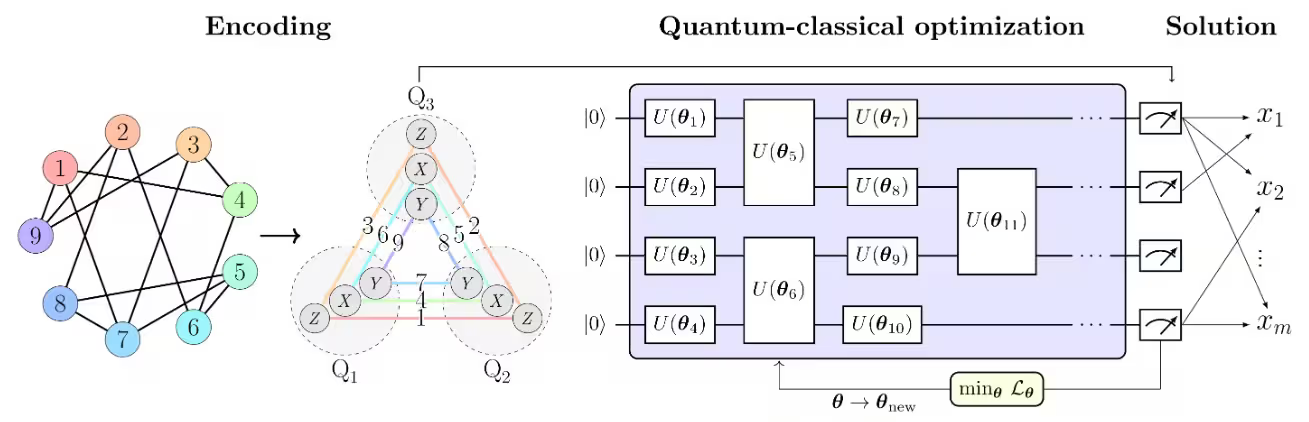
</div>

For more details, refer to [the Pauli Correlation Encoding tutorial](https://quantum.cloud.ibm.com/docs/tutorials/pauli-correlation-encoding-for-qaoa) based on [Sciorili et al.](https://www.nature.com/articles/s41467-024-55346-z).

In [ ]:
n = 160
# We pre-generated 160 random integers in [0, 100] using np.random.randint(0, 100, size=n)
# For reproducibility, we load this pre-generated numbers here
numbers_large = np.load("utils/numbers_large.npy")

print(f"Numbers to partition: {numbers_large}")
print(f"Total sum: {sum(numbers_large)}")

partition_graph_large = build_partition_graph(numbers_large)

print(
    f"\nGraph created with {len(partition_graph_large.nodes())} nodes and {len(partition_graph_large.edges())} edges"
)

Following what is done in [this tutorial](https://quantum.cloud.ibm.com/docs/tutorials/pauli-correlation-encoding-for-qaoa) and in [this paper](https://www.nature.com/articles/s41467-024-55346-z), we can reduce the number of qubits by order $\mathcal{O}(\sqrt{n})$.

<a id="exercise_3a"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 3a: Implement Pauli Correlation Encoding: Qubit reduction </b> 

**Your Goal:** Reduce the number of qubits from $n$ to $\mathcal{O}(\sqrt{n})$ by using Pauli Correlation Encoding. Check out the paper or the tutorial for the specific formula. 

Also, define the lists `node_x`, `node_y`, and `node_z` to specify which nodes are encoded using Pauli X, Y, and Z operators.



</div>

In [ ]:
# ---- TODO : Task 3a ---
def reduce_qubits_with_pce(initial_qubits: int) -> int:
    """
    Reduce the number of qubits from n to O(sqrt(n)) using Pauli Correlation Encoding.
    
    Parameters
    ----------
    initial_qubits : int
        The original number of qubits before encoding.
    
    Returns
    -------
    int
        The reduced number of qubits after applying PCE.
    Examples
        --------
        >>> reduce_qubits_with_pce(160)
        11
    """
    final_qubits =
    return final_qubits



list_size = 
node_x = 
node_y = 
node_z = 

# ---- TODO : Task 3a ---
num_qubits = reduce_qubits_with_pce(n)
print(f"Number of qubits: {num_qubits}")
print("List 1:", node_x)
print("List 2:", node_y)
print("List 3:", node_z)

In [ ]:
## Verify your answer ##
grade_lab4b_ex3a(reduce_qubits_with_pce, node_x, node_y, node_z)

<a id="exercise_3b"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 3b: Implement Pauli Correlation Encoding: Hamiltonian construction </b> 

**Your Goal:** Implement <code>build_pauli_correlation_encoding</code> to generate 2-body Pauli correlation Hamiltonian terms.
Use the lists <code>node_x</code>, <code>node_y</code>, and <code>node_z</code> to control how logical nodes are encoded using Pauli X, Y, and Z operators.




</div>

In [ ]:
def build_pauli_correlation_encoding(pauli: str, node_list: list, n: int, k=2) -> list:
    """
    Build a list of Pauli Hamiltonian terms encoding k-body correlations
    for a given Pauli operator.

    This function constructs Pauli strings acting with the given `pauli`
    operator on all k-combinations of qubits (up to the size of `node_list`)
    and returns them as SparsePauliOp Hamiltonian terms with unit weight.

    Parameters
    ----------
    pauli : str
        Single-qubit Pauli operator ("X", "Y", or "Z").
    node_list : list
        List of nodes (or indices) used to limit the number of correlations.
    n : int
        Total number of qubits.
    k : int, optional
        Order of correlation (default is 2 for pairwise correlations).

    Returns
    -------
    hamiltonian : list of SparsePauliOp
        List of Hamiltonian terms encoding the Pauli correlations.
    """
    # ---- TODO : Task 3b ---

    # ---- END of TODO : Task 3b ---
    return hamiltonian


pauli_correlation_encoding_x = build_pauli_correlation_encoding("X", node_x, num_qubits)
pauli_correlation_encoding_y = build_pauli_correlation_encoding("Y", node_y, num_qubits)
pauli_correlation_encoding_z = build_pauli_correlation_encoding("Z", node_z, num_qubits)

In [ ]:
## Verify your answer ##
grade_lab4b_ex3b(
    pauli_correlation_encoding_x,
    pauli_correlation_encoding_y,
    pauli_correlation_encoding_z,
)

<a id="exercise_3c"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 3c: Implement Pauli Correlation Encoding: Cost Hamiltonian and QAOA ansatz </b> 

**Your Goal:** Combine the Pauli Correlation Encoding Hamiltonian terms into a single cost Hamiltonian (a SparsePauliOp object) and use it to construct the corresponding QAOA ansatz.


</div>

In [ ]:
layers_large = 2
# ---- TODO : Task 3c ---
hamiltonian_pce = 

circuit_pce = 

# ---- END of TODO : Task 3c ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex3c(hamiltonian_pce, circuit_pce)

Let's transpile the circuit:

In [ ]:
edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})

num_colors = len(set(edge_coloring.values()))


cmap = CouplingMap(partition_graph.edges())
cmap.make_symmetric()
swap_strategy = SwapStrategy(cmap, ())
staged_pm = generate_preset_qaoa_pass_manager(
    backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring
)


pm = staged_pm

circuit_pce = pm.run(UnrollBoxes()(circuit_pce))

We define the loss function following the paper.

In [ ]:
def loss_func_estimator(x, ansatz, hamiltonian, estimator, graph, experiment_result=[], job = None):
    """
    Calculates the specified loss function for the given ansatz, Hamiltonian, and graph.

    The expectation values of each Pauli string in the Hamiltonian are first obtained
    by running the ansatz on the quantum backend. These expectation values are then
    passed through the nonlinear function tanh(alpha * prod_i). The loss function is
    subsequently computed from these transformed values.
    """
    if job is None:
        job = estimator.run(
            [
                (ansatz, hamiltonian[0], x),
                (ansatz, hamiltonian[1], x),
                (ansatz, hamiltonian[2], x),
            ]
        )
        print("Creating new Job:", job.job_id())
    else:
        print("Using existing Job:", job.job_id())
    try:
        result = job.result()
    except:
        print(
            "Error: Unable to retrieve results from the job. "
            "Please verify that you are passing the correct job variable to the function."
        )
        return None, None, None

    # calculate the loss function
    node_exp_map = {}
    idx = 0
    for r in result:
        for ev in r.data.evs:
            node_exp_map[idx] = ev
            idx += 1

    loss = 0
    alpha = num_qubits
    for edge0, edge1, weight in graph.edges(data="weight"):
        loss += (
            weight
            * np.tanh(alpha * node_exp_map[edge0])
            * np.tanh(alpha * node_exp_map[edge1])
        )
    regulation_term = 0
    for i in range(len(graph.nodes())):
        regulation_term += np.tanh(alpha * node_exp_map[i]) ** 2
    regulation_term = regulation_term / len(graph.nodes())
    regulation_term = regulation_term**2
    beta = 1 / 2
    v = len(graph.edges()) / 2 + (len(graph.nodes()) - 1) / 4
    regulation_term = beta * v * regulation_term

    loss = loss + regulation_term

    print(f"Iter {len(experiment_result)}: {loss}")
    experiment_result.append(
        {"loss": loss, "exp_map": node_exp_map, "job_result": result}
    )
    return loss, experiment_result, job

In [ ]:
# Build PCE operators with layout applied
# Note that here we need a list of 3 Hamiltonians, one for each Pauli term, instead of a single Hamiltonian such
pce = [
    [op.apply_layout(circuit_pce.layout) for op in pauli_correlation_encoding_x],
    [op.apply_layout(circuit_pce.layout) for op in pauli_correlation_encoding_y],
    [op.apply_layout(circuit_pce.layout) for op in pauli_correlation_encoding_z],
]


def run_pce_optimization(
    qc,
    backend,
    pce,
    partition_graph,
    loss_func_estimator,
    seed=seed,
    max_iter=30,
    training=False,
    filename="utils/pretrained_parameters_pce",
):

    counter = {"i": 0}
    last_x = {"value": None}
    last_fun = {"value": None}

    np.random.seed(seed)
    initial_params = 2 * np.pi * np.random.rand(qc.num_parameters)

    experiment_result = []

    if training:
        # Try with session, fallback to job if it fails
        try:
            session = Session(backend=backend)
            estimator = Estimator(mode=session)
            use_session = True
            print("We are using Session mode")
        except:
            estimator = Estimator(mode=backend)
            use_session = False
            print("We are using Job mode")

        estimator.options.default_shots = 10000
        estimator.options.environment.job_tags = ["qgss26"]

        def loss_func(x, experiment_result):
            last_x["value"] = x.copy()
            if counter["i"] + 1 > max_iter:
                return last_fun["value"]

            counter["i"] += 1

            val, experiment_result, _ = loss_func_estimator(
                x, qc, pce, estimator, partition_graph, experiment_result
            )

            last_fun["value"] = val
            return val

        if use_session:
            with session:
                result = minimize(
                    loss_func,
                    initial_params,
                    experiment_result,
                    method="COBYLA",
                    options={"maxiter": max_iter},
                )
        else:
            result = minimize(
                loss_func,
                initial_params,
                experiment_result,
                method="COBYLA",
                options={"maxiter": max_iter},
            )

        optimized_params = result.x
        np.save(filename, optimized_params)

    else:
        optimized_params = np.load(filename)

    return optimized_params, experiment_result


# You can use the pretrained parameters or run the optimization by setting `training=True`
optimized_params_pce, experiment_result_pce = run_pce_optimization(
    circuit_pce,
    backend,
    pce,
    partition_graph_large,
    loss_func_estimator,
    training=False,
    filename="utils/pretrained_parameters_pce.npy",
)


## 4. Error Mitigation Comparison for PCE-Expanded Partition Problem

Building on the PCE-scaled partition problem from Section 3, we now use the Estimator primitive to systematically compare different [error mitigation techniques](https://quantum.cloud.ibm.com/learning/courses/utility-scale-quantum-computing/error-mitigation) and identify the best possible cut, progressing from basic readout error mitigation to advanced probabilistic error cancellation and zero noise extrapolation. Check out [this tutorial](https://quantum.cloud.ibm.com/docs/tutorials/combine-error-mitigation-techniques) to see how these techniques work in practice.


<a id="exercise_4"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 4: Use the Estimator with different levels of Error Mitigation techniques</b>

**Your Goal:** Apply different error mitigation techniques to the quantum circuit execution using the Estimator primitive and compare the results.

Test the following four configurations with increasing sophistication:

- **4a: No Error Mitigation** (baseline)  
  Raw hardware results without any mitigation

- **4b: TREX (Twirled Readout Error eXtinction) + PT (Pauli Twirling on gates and measures)**  
  Mitigates measurement readout errors through randomized twirling

- **4c: ZNE (Zero Noise Extrapolation) + PT (Pauli Twirling on gates and measures)**  
  Extrapolates results to the zero-noise limit using multiple noise-scaled circuits

- **4d: PEC (Probabilistic Error Cancellation) + PT (Pauli Twirling on gates and measures)**  
  Uses quasi-probability decomposition to cancel gate errors probabilistically

Compare the accuracy, computational overhead, and performance of each approach to understand the trade-offs between different error mitigation strategies.

*Note that for each configuration, you must explicitly enable the desired techniques in `EstimatorOptions`. Just setting the resilience level will not be accepted by the grader.*
</div>

First we build the `EstimatorOptions` without any error mitigation or suppression technique, just defining the number of shots to 1000.

In [ ]:
# No Error Mitigation (Resilience Level 0)
print("=" * 80)
print("Scenario 1: No Error Mitigation (Resilience Level 0)")
print("=" * 80)

est_options_no_em = EstimatorOptions()
# ---- TODO : Task 4a ---
# Configure estimator options without error mitigation and using your preferred number of shots
est_options_no_em.default_shots = 
# ---- END of TODO : Task 4a ---


In [ ]:
## Verify your answer ##
grade_lab4b_ex4a(est_options_no_em)

Now we build the EstimatorOptions using [Twirled Readout Error eXtinction (TREX)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#twirled-readout-error-extinction-trex), which reduces measurement errors by randomly flipping qubits before readout, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling), which converts arbitrary noise channels into noise channels with more specific structure.

In [ ]:
#  TREX (Twirled Readout Error eXtinction)
print("=" * 80)
print("Running with TREX (Twirled Readout Error eXtinction)")
print("=" * 80)
estimator_trex = Estimator(backend)
est_options_trex = EstimatorOptions()
# ---- TODO : Task 4b ---
# Configure estimator options with TREX (measurement error mitigation)
est_options_trex.default_shots = 
# Enable TREX - uses twirling to mitigate readout errors
est_options_trex.resilience.measure_mitigation = 
# Enable gate twirling (both gates and measure)
est_options_trex.twirling.enable_gates = 
est_options_trex.twirling.enable_measure = 

# ---- END of TODO : Task 4b ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex4b(est_options_trex)

Now we implement [Zero Noise Extrapolation (ZNE)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#zero-noise-extrapolation-zne), which intentionally amplifies circuit noise at different levels and extrapolates the results back to estimate the zero-noise limit, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling).

In [ ]:
# Scenario 3: ZNE (Zero Noise Extrapolation) + Gate Twirling
print("=" * 80)
print("Scenario 3: ZNE (Zero Noise Extrapolation) + Gate Twirling")
print("=" * 80)
estimator_zne = Estimator(backend)
est_options_zne = EstimatorOptions()
# ---- TODO : Task 4c ---
# Configure estimator options with ZNE and gate twirling
est_options_zne.default_shots = 

# Apply ZNE to extrapolate results to the zero-noise limit by running circuits at different noise levels
est_options_zne.resilience.zne_mitigation = 

# Enable gate twirling (both gates and measure)
est_options_zne.twirling.enable_gates = 
est_options_zne.twirling.enable_measure = 
# ---- END of TODO : Task 4c ---


In [ ]:
## Verify your answer ##
grade_lab4b_ex4c(est_options_zne)

Finally, we implement [Probabilistic Error Cancellation (PEC)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#probabilistic-error-cancellation-pec), which mitigates errors by probabilistically inverting noisy operations using quasi-probability distributions, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling).

In [ ]:
# Scenario 4: PEC (Probabilistic Error Cancellation) + Gate Twirling
print("=" * 80)
print("Scenario 4: PEC (Probabilistic Error Cancellation) + Gate Twirling")
print("=" * 80)

est_options_pec = EstimatorOptions()
# ---- TODO : Task 4d ---
# Configure estimator options with PEC and gate twirling
est_options_pec.default_shots = 
# Disable ZNE since we want to use PEC instead (set to False)
est_options_pec.resilience.zne_mitigation = 
# Activate pec_mitigation to use PEC
est_options_pec.resilience.pec_mitigation = 


# Enable gate twirling (both gates and measure)
est_options_pec.twirling.enable_gates = 
est_options_pec.twirling.enable_measure = 

# ---- END of TODO : Task 4d ---


In [ ]:
## Verify your answer ##
grade_lab4b_ex4d(est_options_pec)

With all `EstimatorOptions` properly configured, we can now execute the workflows on real quantum hardware. Before running the following cells, carefully review the estimated QPU time consumption to manage your quantum computing resources effectively.


*Usage estimate: 12 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_no_em = Estimator(backend, options=est_options_no_em)
estimator_no_em.options.environment.job_tags = ["qgss26"]

# Calculate loss with optimized parameters
experiment_no_em = []
loss_no_em, experiment_no_em, job_no_em = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_no_em,
    partition_graph_large,
    experiment_no_em,
)

**Troubleshooting: Retrieving Lost Jobs**

If you lose access to your job variables due to a kernel restart or session interruption, you can still retrieve your results without rerunning the job on hardware, saving valuable QPU time.

To recover your results, first retrieve the job using its job_id as shown previously. Then, execute a workflow by passing the retrieved job to the `loss_func_estimator` function, as demonstrated in the cell below.

In [ ]:
job_no_em_retrieved = service.job(job_no_em.job_id()) # or substitute the argument for the string (e.g. "")
experiment_no_em = []
loss_no_em, experiment_no_em, job_no_em = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_no_em,
    partition_graph_large,
    experiment_no_em,
    job_no_em_retrieved,
)

*Usage estimate: 12 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_trex = Estimator(backend, options=est_options_trex)
estimator_trex.options.environment.job_tags = ["qgss26"]

# Calculate loss with TREX
experiment_trex = []
loss_trex, experiment_trex, job_trex = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_trex,
    partition_graph_large,
    experiment_trex,
)

*Usage estimate: 16 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_zne = Estimator(backend, options=est_options_zne)
estimator_zne.options.environment.job_tags = ["qgss26"]
# Calculate loss with ZNE
experiment_zne = []
loss_zne, experiment_zne, job_zne = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_zne,
    partition_graph_large,
    experiment_zne,
)

<div class="alert alert-block alert-warning">

*Usage estimate: 4 min and 26 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*
</div>

If you are not comfortable using that amount of QPU time, you can run the job on a simulator instead. However, this will give less accurate results and will not show how PEC mitigates real hardware noise. To run it on simulator, change the backend and add a coupling map by uncommenting the next cell.

If you want to use the QPU and better understand PEC in practice, skip the commented cell and run the job as-is.

In [ ]:
# backend = AerSimulator.from_backend(backend)
# est_options_pec.simulator = {
#    "coupling_map": CouplingMap.from_full(backend.configuration().n_qubits)
#}

In [ ]:
estimator_pec = Estimator(backend, options=est_options_pec)
estimator_pec.options.environment.job_tags = ["qgss26"]

# Calculate loss with PEC
experiment_pec = []
loss_pec, experiment_pec, job_pec = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_pec,
    partition_graph_large,
    experiment_pec,
)

Let's analyze the results now!

In [ ]:
# Step 1: Analyze baseline (No Error Mitigation)
results = {}
results["No EM"] = analyze_error_mitigation_result(
    loss=loss_no_em,
    experiment_result=experiment_no_em,
    partition_graph=partition_graph_large,
    numbers=numbers_large,  # List of actual numbers being partitioned
)

# Step 2: Analyze TREX with baseline comparison
results["TREX"] = analyze_error_mitigation_result(
    loss=loss_trex,
    experiment_result=experiment_trex,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 3: Analyze ZNE + GT with baseline comparison
results["ZNE"] = analyze_error_mitigation_result(
    loss=loss_zne,
    experiment_result=experiment_zne,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 4: Analyze PEC + GT with baseline comparison
results["PEC"] = analyze_error_mitigation_result(
    loss=loss_pec,
    experiment_result=experiment_pec,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 5: Create comparison dataframe
comparison_df = compare_error_mitigation_methods(results, baseline_key="No EM")

# Step 6: Print summary with key findings
print_comparison_summary(comparison_df)

# Step 7: Plot comprehensive visualizations
plot_error_mitigation_comparison(comparison_df)

# Access individual results:
print("\n" + "=" * 80)
print("DETAILED RESULTS:")
print("=" * 80)

for method_name, result in results.items():
    print(f"\n{method_name}:")
    print(f"  Loss: {result['loss']:.2f}")
    print(f"  Best Cut: {result['best_cut']:.2f}")
    print(f"  Partitions: {result['par0_size']} vs {result['par1_size']} nodes")
    print(f"  Difference in the sums of the partitions: {result['difference']}")
    print(
        f"  Set 0: {result['set0'][:10]}..."
        if len(result["set0"]) > 10
        else f"  Set 0: {result['set0']}"
    )
    print(
        f"  Set 1: {result['set1'][:10]}..."
        if len(result["set1"]) > 10
        else f"  Set 1: {result['set1']}"
    )

    if "loss_improvement_pct" in result:
        print(f"  Improvement: {result['loss_improvement_pct']:.2f}%")
        print(f"  Cut Difference: {result['cut_diff']:.2f}")

##### Your results should look similar to those below. These were obtained from a previous job run on `ibm_pittsburgh`.

<div style="text-align:center;">
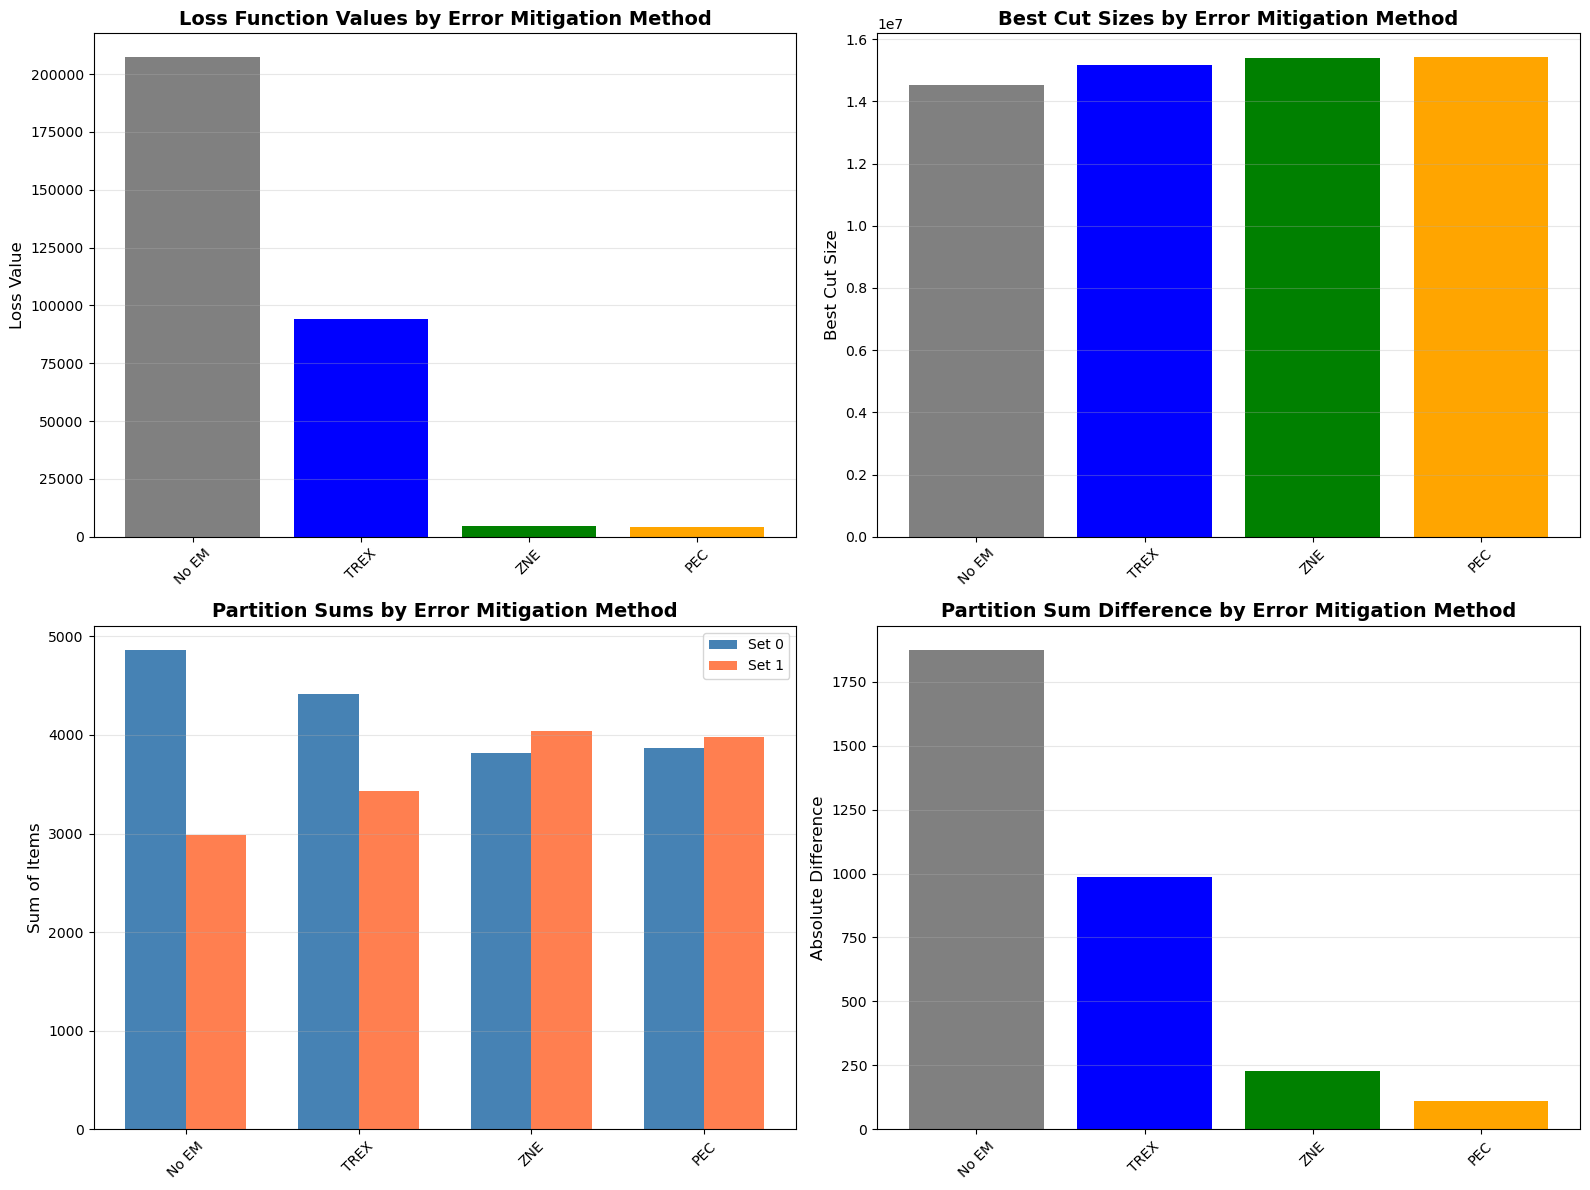
</div>

In [ ]:
estimator_options_list = [
    est_options_no_em,
    est_options_trex,
    est_options_zne,
    est_options_pec,
]
jobs_est_list = [job_no_em, job_trex, job_zne, job_pec]

The grader cell below will verify that your jobs correctly apply the previously defined `EstimatorOptions` and assess the quality of your results to confirm you obtained a valid solution to the partition problem.

In [ ]:
## Verify your answer ##
grade_lab4b_ex4(estimator_options_list, results, jobs_est_list)

## Conclusion

Congratulations on completing Lab 4b! 🎉

In this lab, you explored the partition problem and learned how to formulate it as a QUBO problem suitable for current quantum computers using the QAOA algorithm. You have also experienced how advanced error mitigation and suppression techniques can significantly improve QAOA performance on real quantum hardware. Additionally, you implemented smart encoding strategies that reduce the qubit requirements, enabling you to solve problem instances on current QPUs that would be intractable with naive encoding approaches.

This Lab serves as a demonstration that a combination of the adequate quantum algorithm combined with tailored error-handling strategies and efficient encodings could brings us one step closer to solving real-world problems and demonstrating quantum advantage for classically verifiable problems.

Now, if you enjoyed this problem and are ready to take it to the next level, the bonus section will show you how to tackle a problem 10 times larger: finding the partition of a list containing 1600 numbers!


# Bonus Challenge: Further scaling to a 1600‑node graph

#### Not required for the badge

We now consider a problem with 1600 nodes, which is ten times larger than the example studied previously. Problems of this size start to become significantly more challenging to solve or approximate accurately.

<a id="exercise_bonus"></a>
<div class="alert alert-block alert-success">
    
<b> Bonus exercise: Achieve the best possible result for the partition problem</b>

**Your Goal:** Minimize the difference between the two partition sums as much as possible.

You can do that by following the following techniques:

- **a) Train on hardware** to obtain the optimized parameters for the QAOA circuit.
- **b) Combine multiple error mitigation techniques** to minimize quantum noise effects.
- **c) Implement post-processing refinement** to correct potential bit-flip errors.

For this bonus challenge, scores will range from 0 to 100, where 100 is the best outcome. Your score reflects how well you minimize the difference between the two partitions: the smaller the difference, the better the result. 

*Only results obtained through execution on real hardware will be graded. At least ~ 1 min is needed and ~ 25 min are optional but recommended.*
</div>

In [ ]:
n_bonus = 1600
# We pre-generated 1600 random integers in [0, 100] using np.random.randint(0, 100, size=n_bonus)
# For reproducibility, we load this pre-generated numbers here
numbers_bonus = np.load("utils/numbers_bonus.npy")

print(f"Numbers to partition: {numbers_bonus}")
print(f"Total sum: {sum(numbers_bonus)}")

partition_graph_bonus = build_partition_graph(numbers_bonus)

print(
    f"\nGraph created with {len(partition_graph_bonus.nodes())} nodes and {len(partition_graph_bonus.edges())} edges"
)

list_size_bonus = n_bonus // 3
node_x_bonus = [i for i in range(list_size_bonus)]
node_y_bonus = [i for i in range(list_size_bonus, 2 * list_size_bonus)]
node_z_bonus = [i for i in range(2 * list_size_bonus, n_bonus)]
num_qubits_bonus = reduce_qubits_with_pce(n_bonus)
print(f"Number of qubits after PCE: {num_qubits_bonus}")
pauli_correlation_encoding_x_bonus = build_pauli_correlation_encoding(
    "X", node_x_bonus, num_qubits_bonus
)
pauli_correlation_encoding_y_bonus = build_pauli_correlation_encoding(
    "Y", node_y_bonus, num_qubits_bonus
)
pauli_correlation_encoding_z_bonus = build_pauli_correlation_encoding(
    "Z", node_z_bonus, num_qubits_bonus
)

layers_bonus = 2
ops_bonus = (
    pauli_correlation_encoding_x_bonus
    + pauli_correlation_encoding_y_bonus
    + pauli_correlation_encoding_z_bonus
)
labels_bonus = []
coeffs_bonus = []
for op in ops_bonus:
    # Each op in your list has exactly one term
    labels_bonus.extend(op.paulis.to_labels())  # returns list of strings
    coeffs_bonus.extend(op.coeffs.tolist())  # numpy -> python floats

hamiltonian_pce_bonus = SparsePauliOp(labels_bonus, coeffs_bonus).simplify()
qc_bonus = annotated_qaoa_ansatz(hamiltonian_pce_bonus, reps=layers_bonus)
edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})
num_colors = len(set(edge_coloring.values()))
cmap = CouplingMap(partition_graph.edges())
cmap.make_symmetric()
swap_strategy = SwapStrategy(cmap, ())
staged_pm_bonus = generate_preset_qaoa_pass_manager(
    backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring
)
pm_bonus = staged_pm_bonus
qc_bonus = pm_bonus.run(UnrollBoxes()(qc_bonus))

pce_bonus = [
    [op.apply_layout(qc_bonus.layout) for op in pauli_correlation_encoding_x_bonus],
    [op.apply_layout(qc_bonus.layout) for op in pauli_correlation_encoding_y_bonus],
    [op.apply_layout(qc_bonus.layout) for op in pauli_correlation_encoding_z_bonus],
]

In [ ]:
backend_bonus = service.least_busy(
    simulator=False, operational=True, min_num_qubits=156
)

<div class="alert alert-block alert-warning">
<b>Warning:</b> Each training iteration takes approximately 32 seconds. 
For 30 iterations, the total estimated QPU runtime is about <b>16 minutes</b>. 
Please plan your execution time accordingly.
</div>


**QPU Time-Saving Option:** If you have limited QPU time, you can skip hardware training by using random parameters with `training=False` and only measure the expectation value on hardware later. Note that skipping training and using random parameters will likely give worse results than optimized parameters. To use this option, uncomment and execute the next cell.


In [ ]:
# Generate random parameters (you can use random values or pi/2 as before)
# random_params = np.random.uniform(0, 2*np.pi, qc_bonus.num_parameters)  
# np.save('random_params_for_bonus.npy', random_params)
# opt_params_bonus, experiment_result_bonus_training = run_pce_optimization(
#     qc_bonus,
#     backend_bonus,
#     pce_bonus,
#     partition_graph_bonus,
#     loss_func_estimator,
#     training=False,
#     filename="random_params_for_bonus.npy",
#     max_iter=50,
# )

If you want to train on hardware instead, execute the next cell.

*Usage estimate: 35 minutes on a Heron r2 processor using Session mode (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
opt_params_bonus, experiment_result_bonus_training = run_pce_optimization(
    qc_bonus,
    backend_bonus,
    pce_bonus,
    partition_graph_bonus,
    loss_func_estimator,
    training=True,
    filename="opt_params_bonus_1600_hw.npy",
    max_iter=30,
)

### b) Custom Error Mitigation configuration

In this part you are free to explore different error mitigation strategies to try to obtain the best results.

*Usage estimate: 38 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# Optimal Error Mitigation Configuration
print("=" * 80)
print("Bonus Scenario: Optimal Error Mitigation Strategy")
print("=" * 80)

# Initialize estimator options
est_options_bonus = EstimatorOptions()

# ---- TODO : Task Bonus ---
# Configure estimator with optimal error mitigation settings

# Set number of measurement shots (higher = better statistics but slower)

# Enable resilience level 2 (required for ZNE)

# Otherwise Configure Probabilistic Error Cancellation (PEC)

# Enable measurement error mitigation (corrects readout errors)

# Configure twirling (randomizes coherent errors into stochastic noise)

# ---- END of TODO : Task Bonus ---

# Create estimator with configured options
estimator_bonus = Estimator(backend_bonus, options=est_options_bonus)
estimator_bonus.options.environment.job_tags = ["qgss26"]
print("\nEstimator Configuration:")
print(f" {est_options_bonus}")

# Evaluate the quantum circuit with error mitigation
experiment_bonus = []
loss_bonus, experiment_bonus, job_bonus = loss_func_estimator(
    opt_params_bonus,
    qc_bonus,
    pce_bonus,
    estimator_bonus,
    partition_graph_bonus,
    experiment_bonus,
)

# Display results
print(f"\nLoss with Advanced Error Mitigation: {loss_bonus:.4f}")

### c) Post-Processing: single-bit flips around the solutions

Even with advanced error mitigation, quantum noise can cause bit-flip errors in the solution. We implement a **local search** strategy to refine the quantum solution:

1. Start with the best solution from the quantum computer
2. Systematically try swapping nodes between partitions
3. Keep swaps that improve the cut size (objective function)
4. This corrects potential errors introduced by quantum noise


In [ ]:
# Extract the best partition from quantum results

# Get the partitions with highest expectation value
par0, par1, best_index = get_partitions(experiment_bonus)

# Calculate the cut size for this partition
cut_size = calc_cut_size(partition_graph_bonus, par0, par1)

# Convert expectation values to binary representation
# Positive expectation → bit = 1 (partition 0)
# Negative expectation → bit = 0 (partition 1)
cur_bits = []
for i in experiment_bonus[best_index]["exp_map"]:
    if experiment_bonus[best_index]["exp_map"][i] >= 0:
        cur_bits.append(1)
    else:
        cur_bits.append(0)

Let us now implement the `swap_partitions` function.

Since the graph is quite large and contains many edges, you might consider the following strategies to reduce the computational cost of the `swap_partitions` function.

1. Convert the NetworkX graph to a Rustworkx graph, since it is optimized for large graph operations.
2. Use a subset of edges by sampling a portion of the edges, instead of processing the full edge set.

In case you don't have it installed, you can install [Rustworkx](https://www.rustworkx.org/tutorial/introduction.html) by uncommenting the next cell:

In [ ]:
# %pip install rustworkx

In [ ]:
def swap_partitions(graph: nx.Graph, cur_bits, max_samples=1000):
    """
    Local search refinement: swap nodes between partitions to improve cut size.

    This function explores the neighborhood of the current solution by trying
    all possible swaps of connected nodes. This helps correct bit-flip errors
    that may have been introduced by quantum noise.

    Parameters
    ----------
    graph : networkx.Graph
        The graph representing the partition problem
    cur_bits : List[int]
        Current partition assignment (1 = partition 0, 0 = partition 1)
    max_samples : int
        Maximum number of edges to sample
    Returns
    -------
    Tuple[float, List[int]]
        best_cut : Best cut size found after exploring swaps
        best_bits : Partition assignment that achieves the best cut
    """

    # ---- TODO : Task Bonus ---
    # --------------------------------------------------
    # 1. Convert NetworkX graph → rustworkx graph
    # --------------------------------------------------
    import rustworkx as rx
    def nx_to_rx(graph_nx):
        rx_graph = rx.PyGraph()

        # Add nodes

        # Add edges

        return rx_graph

    graph = nx_to_rx(graph)

    # --------------------------------------------------
    # 2. Fast cut size computation (no sets!)
    # --------------------------------------------------


    # ---- END of TODO : Task Bonus ---
    return best_cut, best_bits

A fast implementation of the `swap_partitions` function using max_samples=1000 should take around 1 minute.

In [ ]:
# Apply local search refinement to quantum solution
best_cut, best_bits = swap_partitions(partition_graph_bonus, cur_bits, max_samples=1000)

# Convert refined bit assignment back to number sets
set0 = [int(numbers_bonus[i]) for i in range(len(numbers_bonus)) if best_bits[i] == 1]
set1 = [int(numbers_bonus[i]) for i in range(len(numbers_bonus)) if best_bits[i] == 0]

# Compile final results
result_bonus = {
    "loss": loss_bonus,  # Quantum loss function value
    "par0": list(par0),  # Original partition 0 from quantum
    "par1": list(par1),  # Original partition 1 from quantum
    "par0_size": len(par0),  # Size of partition 0
    "par1_size": len(par1),  # Size of partition 1
    "best_cut": np.float64(best_cut),  # Best cut after refinement
    "best_index": best_index,  # Index of best quantum result
    "set0": set0,  # Refined set 0 (actual numbers)
    "set1": set1,  # Refined set 1 (actual numbers)
    "difference": abs(int(sum(set0) - sum(set1))),  # Final partition difference
    "exp_map": experiment_bonus[best_index]["exp_map"],
}

# Display the final partition difference (goal: minimize to 0 or 1)
print(f"Final partition difference after refinement: {result_bonus['difference']}")
print(f"Sum of set 0: {sum(set0)}")
print(f"Sum of set 1: {sum(set1)}")

In [ ]:
## Verify your answer ##
grade_lab4b_exbonus(result_bonus, best_bits, numbers_bonus, job_bonus)

Well done! You have completed the Bonus challenge! 

# Additional information

**Created by:** Jorge Martínez de Lejarza

**Version:** 1.0.0